Loading a Kaggle Dataset into Colab

In [ ]:
# Upload a Kaggle Json File(Kaggle API Key)
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"saiprasannaudara","key":"37b86a60baaae9092bd188384a5aa2c0"}'}

In [ ]:
# Kaggle Credentials Path
import os
os.environ['KAGGLE_CONFIG_DIR'] = '/content'

# Install Kaggle Python Libraries
!pip install kaggle

# Set Permissions
!chmod 600 /content/kaggle.json

In [ ]:
# Dataset download
!kaggle datasets download nicapotato/womens-ecommerce-clothing-reviews

Dataset URL: https://www.kaggle.com/datasets/nicapotato/womens-ecommerce-clothing-reviews
License(s): CC0-1.0
  0% 0.00/2.79M [00:00<?, ?B/s]
100% 2.79M/2.79M [00:00<00:00, 534MB/s]


In [ ]:
# Unzip the downloaded file
!unzip womens-ecommerce-clothing-reviews.zip

Archive:  womens-ecommerce-clothing-reviews.zip
  inflating: Womens Clothing E-Commerce Reviews.csv  


Importing Required Libraries and loading the data into Dataframe

In [ ]:
# Importing pandas, numpy and matplot libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the data
df = pd.read_csv('/content/Womens Clothing E-Commerce Reviews.csv')

Step-1 : Exploratory Data Analysis

(a)DataSet Structure Analysis

In [ ]:
# Dataset Structure
# Print Shape of the data
print(f"shape: {df.shape}")

# Print Number of rows and columns
print(f"Number of Rows: {df.shape[0]:}")
print(f"Number of Columns: {df.shape[1]}")

# Print Column Names
print(f"Header Columns: {df.columns.tolist()}")

shape: (23486, 11)
Number of Rows: 23486
Number of Columns: 11
Header Columns: ['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name']


In [ ]:
# Delete Unnamed Column
del df['Unnamed: 0']

# Print first five rows
print(f"First Five rows:")
df.head()

First Five rows:


,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


(b) Datatype Analysis

In [ ]:
# Print the data types
print(df.dtypes.value_counts())
print(f"data types:\n{df.dtypes}")

int64     5
object    5
Name: count, dtype: int64
data types:
Clothing ID                 int64
Age                         int64
Title                      object
Review Text                object
Rating                      int64
Recommended IND             int64
Positive Feedback Count     int64
Division Name              object
Department Name            object
Class Name                 object
dtype: object


In [ ]:
#print Text columns and Numeric Columns
text_columns = df.select_dtypes(include=['object']).columns
numeric_columns = df.select_dtypes(include=['int64']).columns

print(f"Text Columns:\n {text_columns.tolist()}")
print(f"Numeric Columns:\n {numeric_columns.tolist()}")

Text Columns:
 ['Title', 'Review Text', 'Division Name', 'Department Name', 'Class Name']
Numeric Columns:
 ['Clothing ID', 'Age', 'Rating', 'Recommended IND', 'Positive Feedback Count']


(C) Missing Value Analysis

In [ ]:
# Missing Values Analysis
print(f"Missing Null Values:\n{df.isnull().sum()}")

Missing Null Values:
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64


(d) Duplicate records

In [ ]:
# Print number of records in Review text column
print(f"Number of Review texts: {len(df['Review Text'])}")

# Duplicate records in review text column
if 'Review Text' in df.columns:
    text_duplicates = df['Review Text'].duplicated().sum()
    print(f"Duplicate Text Reviews: {text_duplicates}")

Number of Review texts: 23486
Duplicate Text Reviews: 851


(e) Rating Distribution

In [ ]:
# Print number of records in Rating Column
print(f"Number of Ratings: {len(df['Rating'])}")

Number of Ratings: 23486


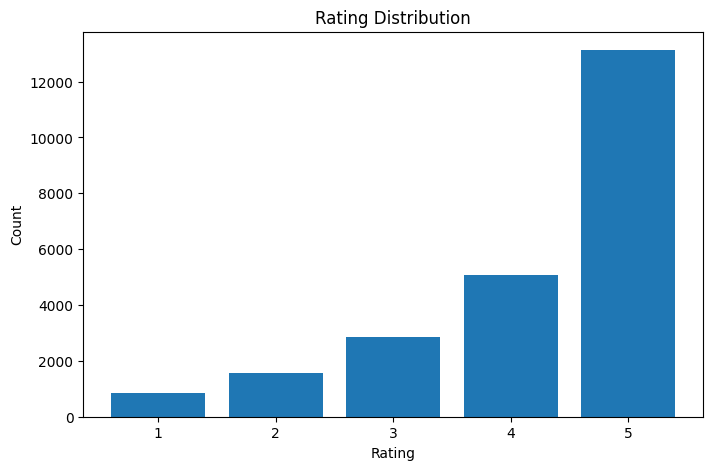

In [ ]:
# Visualize the Rating Distribution
rating_counts = df['Rating'].value_counts().sort_index()
plt.figure(figsize=(8,5))
plt.bar(rating_counts.index, rating_counts.values)
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

(f) Brand Analysis

In [ ]:
# Print number of unique records of Clothing ID
unique_ID = len(df['Clothing ID'].unique())
len_Clothing_ID = len(df['Clothing ID'])

print(f"Number of clothing ID's: {len_Clothing_ID}")
print(f"Number of Unique Clothing ID's: {unique_ID}")

Number of clothing ID's: 23486
Number of Unique Clothing ID's: 1206


Top brands by Review Count: 
 Clothing ID
1078    1024
862      806
1094     756
1081     582
872      545
829      527
1110     480
868      430
895      404
936      358
Name: count, dtype: int64


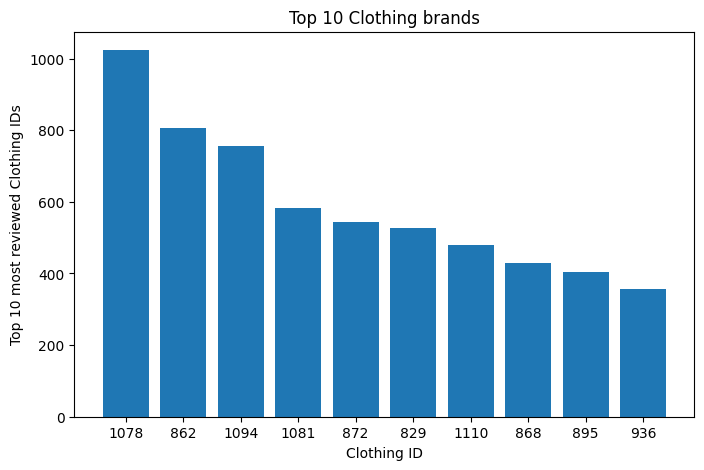

In [ ]:
top_10_ids = df['Clothing ID'].value_counts().head(10)
print(f"Top brands by Review Count: \n {top_10_ids}")
plt.figure(figsize=(8,5))
plt.bar(top_10_ids.index.astype(str), top_10_ids.values)
plt.title('Top 10 Clothing brands')
plt.xlabel('Clothing ID')
plt.ylabel('Top 10 most reviewed Clothing IDs')
plt.show()

(g) Correlation Analysis

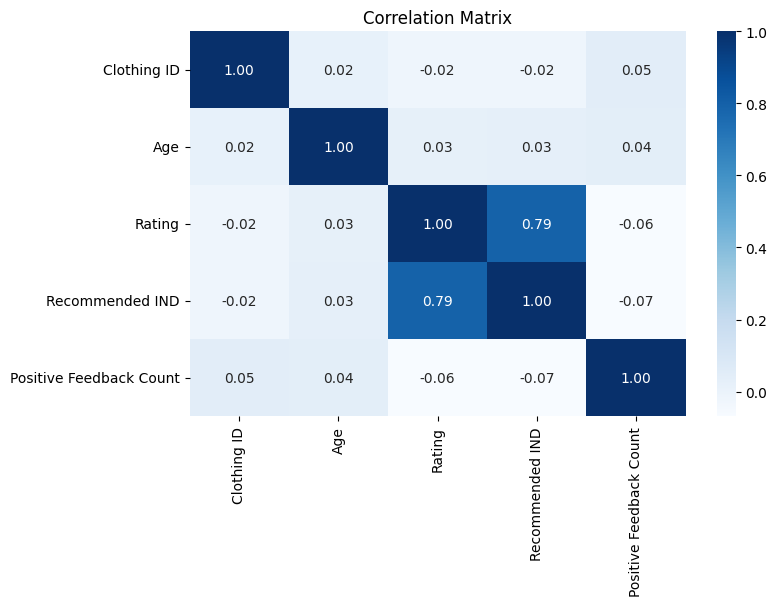

In [ ]:
# Correlation matrix for numeric columns

# Select numeric columns except first column
numeric_df = df.select_dtypes(include=np.number)

# Plot correlation matirx
if len(numeric_df.columns)>1:
    plt.figure(figsize=(8,5))
    correlation_matrix = numeric_df.corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt='.2f')
    plt.title("Correlation Matrix")
    plt.show()

(h) Text Content Analysis

In [ ]:
# Import required packages and libraries
from collections import Counter
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
# Combine all text
all_text = ''.join(df['Review Text'].astype(str))

# Remove stop wrods
stop_words = set(stopwords.words('english'))

# Count words
words = [word.lower() for word in all_text.split() if word.lower()
not in stop_words and len(word) > 2]
word_count = Counter(words)

# Print most common words
print("Most Common Words:")
for word, count in word_count.most_common(20):
    print(f"{word} : {count}")

Most Common Words:
dress : 7747
love : 7350
size : 6757
like : 6675
wear : 5883
fit : 5847
top : 4994
would : 4964
great : 4567
really : 3772
fabric : 3760
little : 3710
ordered : 3697
look : 3399
color : 3238
small : 3072
one : 2986
bought : 2807
looks : 2766
fits : 2712


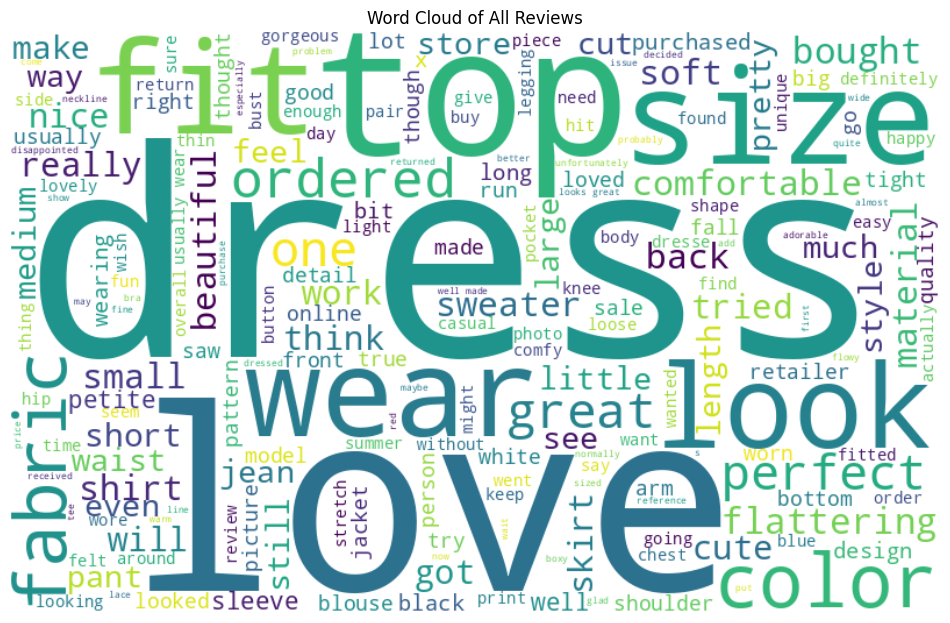

In [ ]:
# Import libraries for word cloud
from wordcloud import WordCloud

# Create word cloud
plt.figure(figsize=(12, 8))
wordcloud = WordCloud(width=800, height=500, background_color='white')\
.generate(all_text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of All Reviews')
plt.show()

(i) Satisfaction Analysis

In [ ]:
# Define a function called sentiment label
def sentiment_label(Rating):
    if Rating >= 4:
        return 'Positive'
    else:
        return 'Negative'

df['sentiment_label'] = df['Rating'].apply(sentiment_label)

df['sentiment_label'].value_counts()

,count
sentiment_label,
Positive,18208
Negative,5278


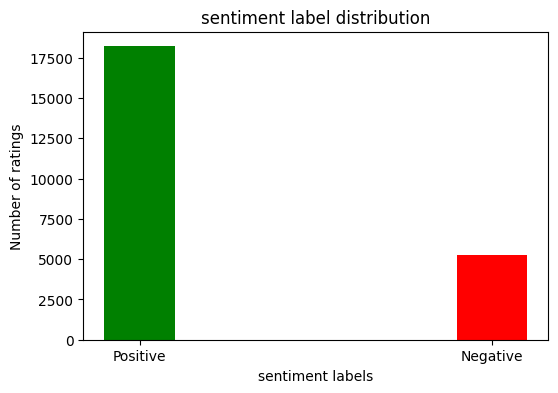

In [ ]:
# Plot the distribution of sentiment labels
sentiment_labels = df['sentiment_label'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(sentiment_labels.index, sentiment_labels.values, color =
 ['green', 'red'], width = 0.2 )
plt.xlabel('sentiment labels')
plt.ylabel('Number of ratings')
plt.title('sentiment label distribution')
plt.show()

Step-2 : Data Cleaning and preprocessing

(a) Remove Missing data

In [ ]:
#Remove Missing data from Review text column
df = df.dropna(subset = ['Review Text'])

#Review Missing data from Rating column
df = df.dropna(subset = ['Rating'])

len(df)

22641

(b) Remove Duplicates

In [ ]:
# Drop Duplicates
df = df.drop_duplicates()
len(df)

22640

(c) Remove Invalid data

In [ ]:
# Remove invalid ratings from rating column
valid_ratings = df['Rating'].between(1,5)
df = df[valid_ratings]
print(f"Removed {(~valid_ratings).sum()} rows with invalid ratings")

Removed 0 rows with invalid ratings


(d) Text Cleaning

In [ ]:
# Import required libraries for text cleaning
import re
import string

# Create a function to clean the text
def clean_text(text):
    """ Clean text data for sentiment analysis """
    text = str(text)
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', '',
                  text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z0-9\s\.\!\?\,]', '', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    return text
df['cleaned text'] = df['Review Text'].apply(clean_text)
print("Cleaning Examples:")
for i in range(3):
    print(f"Original: {df['Review Text'].iloc[i][:100]}...")
    print(f"Cleaned: {df['cleaned text'].iloc[i][:100]}...")
    print("-" *50)

Cleaning Examples:
Original: Absolutely wonderful - silky and sexy and comfortable...
Cleaned: absolutely wonderful silky and sexy and comfortable...
--------------------------------------------------
Original: Love this dress!  it's sooo pretty.  i happened to find it in a store, and i'm glad i did bc i never...
Cleaned: love this dress! its sooo pretty. i happened to find it in a store, and im glad i did bc i never wou...
--------------------------------------------------
Original: I had such high hopes for this dress and really wanted it to work for me. i initially ordered the pe...
Cleaned: i had such high hopes for this dress and really wanted it to work for me. i initially ordered the pe...
--------------------------------------------------


(e) Text processing with NLTK

In [ ]:
# Install and setup NLTK
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
# Tokenization and Stopword Removal
def process_text(text):
    """Advanced Text Processing: Tokenization, Stopword Removal,
    lemmatization"""

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    stop_words = set(stopwords.words('english'))

    # Filter stopwords and short words
    filtered_tokens = [word for word in tokens if word.lower() not in stop_words
                       and len(word) > 2]

    # Lemmitization
    lemmatizer = WordNetLemmatizer()
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in filtered_tokens]

    # Join back into text
    processed_text = ' '.join(lemmatized_tokens)
    return processed_text

In [ ]:
# Example Processing Text
df['processed_text'] = df['cleaned text'].apply(process_text)
print("Processing Examples:")
for i in range(3):
    print(f"Cleaned: {df['cleaned text'].iloc[i][:100]}...")
    print(f"Processed: {df['processed_text'].iloc[i][:100]}...")
    print("-" *50)

Processing Examples:
Cleaned: absolutely wonderful silky and sexy and comfortable...
Processed: absolutely wonderful silky sexy comfortable...
--------------------------------------------------
Cleaned: love this dress! its sooo pretty. i happened to find it in a store, and im glad i did bc i never wou...
Processed: love dress sooo pretty happened find store glad never would ordered online petite bought petite 58. ...
--------------------------------------------------
Cleaned: i had such high hopes for this dress and really wanted it to work for me. i initially ordered the pe...
Processed: high hope dress really wanted work initially ordered petite small usual size found outrageously smal...
--------------------------------------------------


(f) Feature Engineering

In [ ]:
# Text length Features
df['text_length'] = df['cleaned text'].str.len()
df['word_count'] = df['cleaned text'].str.split().str.len()
df['avg_word_length'] = df['text_length']/df['word_count']

# Count Features
df['exclamation_count'] = df['cleaned text'].str.count('!')
df['question_count'] = df['cleaned text'].str.count('\?')
df['uppercase_count'] = df['Review Text'].str.count(r'[A-Z]')

# Sentiment-related features
df['positive_words'] = df['cleaned text'].str.count(r'\b(good|great|excellent|amazing|love|perfect)\b')
df['negative_words'] = df['cleaned text'].str.count(r'\b(bad|terrible|awful|hate|worst|horrible)\b')

print("Feature Engineering Results:")
print(df[['text_length', 'word_count', 'positive_words', 'negative_words']].describe())

Feature Engineering Results:
        text_length    word_count  positive_words  negative_words
count  22640.000000  22640.000000    22640.000000    22640.000000
mean     305.222968     59.994346        0.944567        0.032420
std      141.973590     28.434639        1.010642        0.190109
min        9.000000      2.000000        0.000000        0.000000
25%      184.000000     36.000000        0.000000        0.000000
50%      298.000000     59.000000        1.000000        0.000000
75%      453.000000     88.000000        1.000000        0.000000
max      505.000000    115.000000        8.000000        4.000000


(g) Outlier Detection

In [ ]:
mean_length = np.mean(df['text_length'])
std_dev = np.std(df['text_length'])

z_score = (df['text_length'] - mean_length)/std_dev
outliers = np.abs(z_score > 3)
outliers.value_counts()

,count
text_length,
False,22640


Step - 3: Over sampling and under sampling for imbalanced dataset

In [ ]:
# Import required packages from imbalanced learn library for sampling techniques
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.under_sampling import TomekLinks, RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from collections import Counter

In [ ]:
# Import train test split package from sklearn library
from sklearn.model_selection import train_test_split

# Feature variable(cleaned text) and Target Variable(rating)
x = df['cleaned text']
y = df['Rating']

x_temp, x_test, y_temp, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y)

x_train, x_val, y_train, y_val = train_test_split(
    x_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print(f"Training set size: {len(x_train)}")
print(f"Test set size: {len(x_test)}")
print(f"Training distribution: {dict(Counter(y_train))}")
print(f"Test distribution: {dict(Counter(y_test))}")

Training set size: 13584
Test set size: 4528
Training distribution: {4: 2945, 5: 7523, 3: 1694, 2: 929, 1: 493}
Test distribution: {5: 2508, 3: 564, 4: 982, 2: 310, 1: 164}


In [ ]:
vectorizer = TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        stop_words='english',
        min_df=2,
        max_df=0.9,
        sublinear_tf=True
    )

# Apply vectorizer function on values of x_train
x_train_tfidf = vectorizer.fit_transform(x_train)
original_counts = Counter(y_train)
print(f"Training vectors shape: {x_train_tfidf.shape}")
print(f"Original distribution: {dict(original_counts)}")

Training vectors shape: (13584, 10000)
Original distribution: {4: 2945, 5: 7523, 3: 1694, 2: 929, 1: 493}


In [ ]:
# Define SMOTE and Tomek for over and under sampling tasks
def combined_smotetomek(x_train, y_train):
    print("\n" + "="*50)
    print("METHOD : SMOTETomek")
    print("="*50)

    x_train_tfidf = vectorizer.fit_transform(x_train)
    original_counts = Counter(y_train)
    print(f"Original distribution: {dict(original_counts)}")

 # Apply SMOTETomek
    smotetomek = SMOTETomek(
        sampling_strategy='auto',
        random_state=42,
        tomek=TomekLinks(sampling_strategy='majority'),
        smote=SMOTE(random_state=42)
    )

    x_resampled, y_resampled = smotetomek.fit_resample(x_train_tfidf, y_train)
    print(f"After SMOTETomek: {dict(Counter(y_resampled))}")

    return x_resampled, y_resampled, vectorizer

In [ ]:
x_train_resampled, y_train_resampled, vectorizer = combined_smotetomek(
    x_train, y_train)


METHOD : SMOTETomek
Original distribution: {4: 2945, 5: 7523, 3: 1694, 2: 929, 1: 493}
After SMOTETomek: {4: 7523, 5: 7523, 3: 7523, 2: 7523, 1: 7523}


In [ ]:
# Define Under and Over Sampling
def sequential_sampling(x_train, y_train, target_distribution=None):

    # Print Sequential sampling
    print("\n" + "="*50)
    print("SEQUENTIAL SAMPLING(RandomUnderSampler & SMOTE)")
    print("="*50)

    # Count and print the number of train set of variable Y
    original_counts = Counter(y_train)
    print(f"Original distribution: {dict(original_counts)}")

    # Under Sampling
    if target_distribution is None:
        # Auto-calculate target distribution
        median_count = int(np.median(list(original_counts.values())))
        under_strategy = {k: min(v, median_count * 2) for k, v in original_counts.items()
                         if v > median_count * 2}
    else:
        under_strategy = {k: v for k, v in target_distribution.items()
                         if k in original_counts and v < original_counts[k]}

    if under_strategy:
        undersampler = RandomUnderSampler(
            sampling_strategy=under_strategy,
            random_state=42
        )
        x_train_tfidf, y_train = undersampler.fit_resample(vectorizer.fit_transform(x_train), y_train)
        print(f"After undersampling: {dict(Counter(y_train))}")

    current_counts = Counter(y_train)
    target_count = max(current_counts.values())
    over_strategy = {k: target_count for k, v in current_counts.items()
                    if v < target_count}

    if over_strategy:
        oversampler = SMOTE(
            sampling_strategy=over_strategy,
            random_state=42,
            k_neighbors=min(5, min(current_counts.values()) - 1)
        )
        x_train_tfidf, y_train = oversampler.fit_resample(x_train_tfidf, y_train)
        print(f"After oversampling: {dict(Counter(y_train))}")

    return x_train_tfidf, y_train, vectorizer

In [ ]:
x_train_resampled, y_train_resampled, vectorizer = sequential_sampling(
    x_train, y_train)


SEQUENTIAL SAMPLING(RandomUnderSampler & SMOTE)
Original distribution: {4: 2945, 5: 7523, 3: 1694, 2: 929, 1: 493}
After undersampling: {1: 493, 2: 929, 3: 1694, 4: 2945, 5: 3388}
After oversampling: {1: 3388, 2: 3388, 3: 3388, 4: 3388, 5: 3388}


Step - 4 : Validation of Models using Text Blob, VADER Pretrained models

In [ ]:
# Install and import TextBlob and VADER package
!pip install textblob
from textblob import TextBlob

!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [ ]:
print(f"Sentiment Analysis on {len(df)} reviews")

In [ ]:
# Define Text Blob Sentiment Analysis function
def get_textblob_sentiment(text):
    blob = TextBlob(str(text))
    return blob.sentiment.polarity, blob.sentiment.subjectivity

df[['polarity', 'subjectivity']] = df['cleaned text'].apply(
    lambda x: pd.Series(get_textblob_sentiment(x))
)

In [ ]:
# Define VADER sentiment Analysis Function
analyzer = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    scores = analyzer.polarity_scores(str(text))
    return scores['compound']

df['vader_compound'] = df['cleaned text'].apply(get_vader_sentiment)

In [ ]:
# Validation based on the ratings in the dataset
def rating_to_sentiment(rating):
    if rating >= 4:
        return 'Positive'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Negative'

df['actual_sentiment'] = df['Rating'].apply(rating_to_sentiment)

In [ ]:
# Create TextBlob sentiment categories
def polarity_to_sentiment(polarity):
    if polarity > 0.1:
        return 'Positive'
    elif polarity < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

df['textblob_sentiment'] = df['polarity'].apply(polarity_to_sentiment)

In [ ]:
# Validate accuracy
accuracy = (df['textblob_sentiment'] == df['actual_sentiment']).mean()
print(f"TextBlob Accuracy: {accuracy:.3f}")

In [ ]:
# Show classification report
from sklearn.metrics import classification_report
print("\nTextBlob Performance Report:")
print(classification_report(df['actual_sentiment'], df['textblob_sentiment']))